# Raw Analytics - Amazon Products

Analise de qualidade dos dados brutos da camada Bronze.

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Carregamento

In [123]:
plt.style.use('seaborn-v0_8')
sns.set_theme(context="notebook", style="whitegrid")

df_raw = pd.read_csv('Data Layer/raw/data_raw.csv')
df_raw_temp = df_raw.copy()

## 2. Metricas Gerais

## 3. Dados Faltantes por Coluna

In [124]:
missing_data = pd.DataFrame({
    'Coluna': df_raw.columns,
    'Nulos': df_raw.isnull().sum().values,
    'Total': df_raw.isnull().sum().values + (df_raw == '').sum().values,
    '%': ((df_raw.isnull().sum().values + (df_raw == '').sum().values) / len(df_raw) * 100).round(2)
})

missing_data = missing_data[missing_data['Total'] > 0].sort_values('Total', ascending=False)
missing_data

,Coluna,Nulos,Total,%
12,sustainability_badges,39267,39267,92.01
10,buy_box_availability,14653,14653,34.34
4,current/discounted_price,11749,11749,27.53
11,delivery_details,11720,11720,27.46
3,bought_in_last_month,3217,3217,7.54
14,product_url,2069,2069,4.85
1,rating,1024,1024,2.40
2,number_of_reviews,1024,1024,2.40


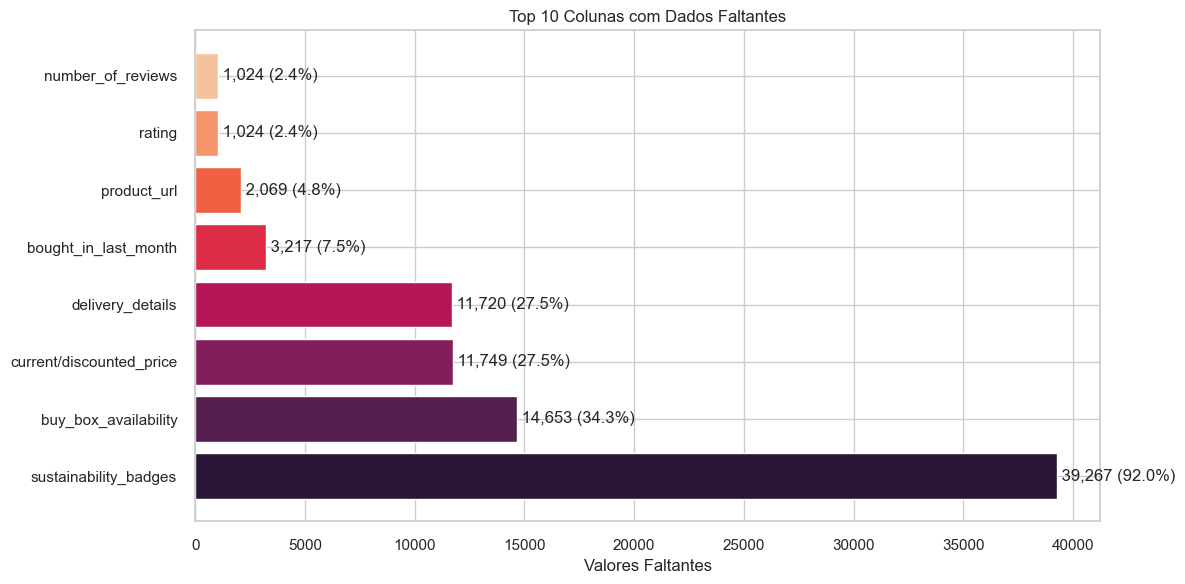

In [125]:
if len(missing_data) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    top_missing = missing_data.head(10)
    colors = sns.color_palette('rocket', n_colors=len(top_missing))
    
    ax.barh(top_missing['Coluna'], top_missing['Total'], color=colors)
    ax.set_xlabel('Valores Faltantes')
    ax.set_title('Top 10 Colunas com Dados Faltantes')
    
    for i, (idx, row) in enumerate(top_missing.iterrows()):
        ax.text(row['Total'], i, f" {row['Total']:,.0f} ({row['%']:.1f}%)", ha='left', va='center')
    
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum valor faltante significativo")

## 5. Faixas de Preco e Fonte

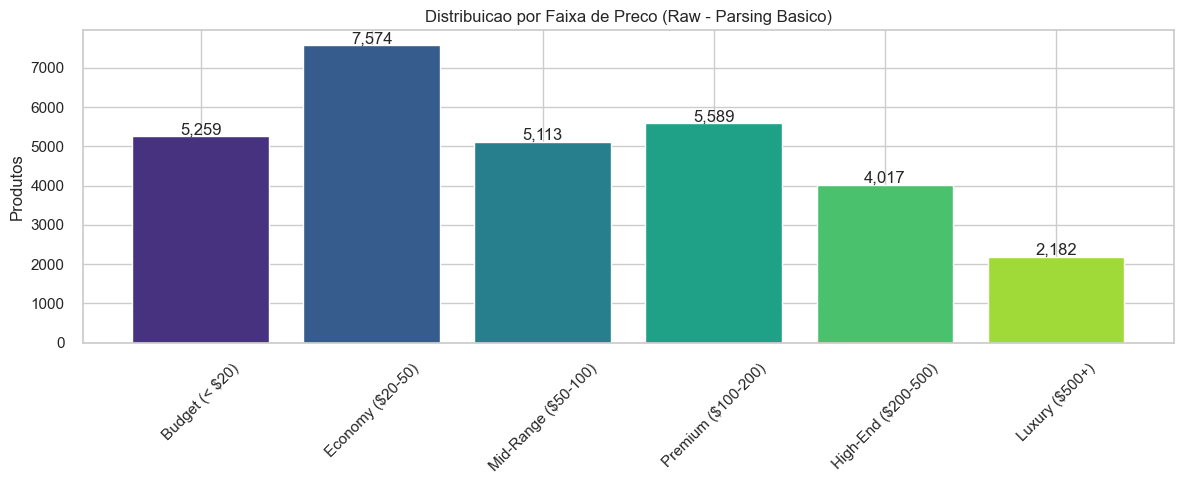

In [126]:
price_cols = [col for col in df_raw.columns if 'price' in col.lower()]

if price_cols:
    main_price_col = 'current/discounted_price' if 'current/discounted_price' in df_raw.columns else price_cols[0]
    
    df_raw_temp['price_numeric'] = pd.to_numeric(df_raw_temp[main_price_col], errors='coerce')
    
    df_raw_temp['price_tier'] = pd.cut(
        df_raw_temp['price_numeric'],
        bins=[0, 20, 50, 100, 200, 500, float('inf')],
        labels=['Budget (< $20)', 'Economy ($20-50)', 'Mid-Range ($50-100)',
                'Premium ($100-200)', 'High-End ($200-500)', 'Luxury ($500+)']
    )
    
    fig, ax = plt.subplots(figsize=(12, 5))
    
    price_tiers = df_raw_temp['price_tier'].value_counts().sort_index()
    
    ax.bar(price_tiers.index, price_tiers.values, color=sns.color_palette('viridis', len(price_tiers)))
    ax.set_title('Distribuicao por Faixa de Preco (Raw - Parsing Basico)')
    ax.set_ylabel('Produtos')
    ax.tick_params(axis='x', rotation=45)
    for x, y in enumerate(price_tiers.values):
        if pd.notna(y):
            ax.text(x, y + 50, f"{int(y):,}", ha='center')
    
    plt.tight_layout()
    plt.show()
else:
    print("Colunas de preco nao encontradas")

## 7. Distribuicao de Ratings e Dispersao

In [127]:
rating_col = next((col for col in df_raw.columns if 'rating' in col.lower()), None)

if rating_col and 'review_count' in df_raw_temp.columns:
    df_raw_temp['rating_numeric'] = df_raw[rating_col].str.extract(r'([\d.]+)').astype(float)
    
    bestseller_col = next((col for col in df_raw.columns if 'best_seller' in col.lower()), None)
    if bestseller_col:
        df_raw_temp['is_best_seller_bool'] = df_raw[bestseller_col].astype(str).str.lower() == 'true'
    else:
        df_raw_temp['is_best_seller_bool'] = False
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histograma de ratings
    sns.histplot(df_raw_temp['rating_numeric'].dropna(), bins=20, ax=axes[0], color="#4c72b0")
    axes[0].set_title('Distribuicao de Ratings (Raw)')
    axes[0].set_xlabel('Rating (1-5)')
    axes[0].set_ylabel('Frequencia')
    
    # Scatter plot
    sns.scatterplot(
        data=df_raw_temp,
        x='rating_numeric',
        y=np.log1p(df_raw_temp['review_count']),
        hue='is_best_seller_bool',
        palette=['#999999', '#ff7f0e'],
        alpha=0.4,
        ax=axes[1]
    )
    axes[1].set_title('Rating vs Reviews (log) - Raw')
    axes[1].set_xlabel('Rating')
    axes[1].set_ylabel('log1p(Reviews)')
    axes[1].legend(title='Best Seller', loc='lower right')
    
    plt.tight_layout()
    plt.show()
else:
    print("Colunas de rating/review nao encontradas para analise de dispersao")

Colunas de rating/review nao encontradas para analise de dispersao


## 10. Distribuicao de Completude por Coluna

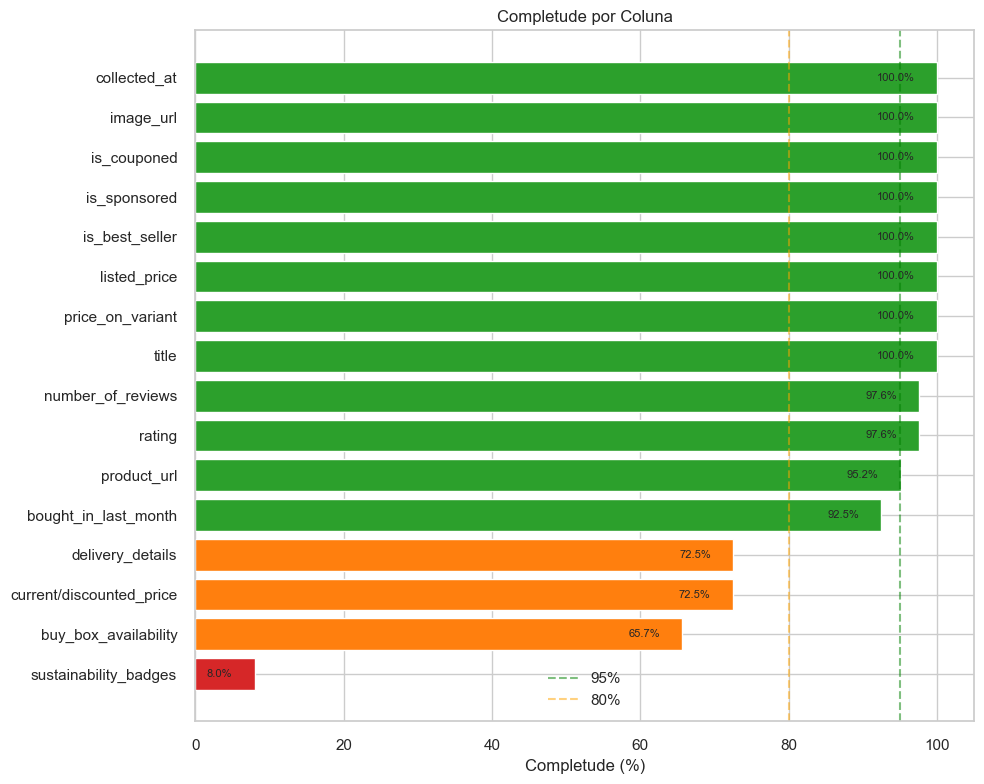

In [128]:
completeness_by_col = ((df_raw.notna().sum() / len(df_raw)) * 100).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors_gradient = ['#d62728' if x < 50 else '#ff7f0e' if x < 80 else '#2ca02c' for x in completeness_by_col]
ax.barh(completeness_by_col.index, completeness_by_col.values, color=colors_gradient)
ax.set_xlabel('Completude (%)')
ax.set_title('Completude por Coluna')
ax.axvline(95, color='green', linestyle='--', alpha=0.5, label='95%')
ax.axvline(80, color='orange', linestyle='--', alpha=0.5, label='80%')

for i, v in enumerate(completeness_by_col.values):
    ax.text(v - 3, i, f"{v:.1f}%", va='center', ha='right', fontsize=8)

ax.legend()
plt.tight_layout()
plt.show()